# Ventralization test: does Matrix expression track physical proximity to the D1D2 dorsal-ventral score?

Reproduces just the ventralization-process test from `ventralization_by_D1D2_score.ipynb`
(its "Clautle Phycsal score for matrix based on d1d1 score neirghbors" section): score eMSN_D1D2
cells along the dorsal-ventral (`r`) gradient using D1D2 gene weights, propagate that score to
nearby Matrix cells by spatial proximity ("physical" DV score), and check whether the two agree —
in Control vs XDP.

Gene ~ `r` correlation weights are **not recomputed** here. They're loaded straight from
`df_corr_r_d1d2.csv`, produced by `find_spatial_grad_gene_MSN_types_refactored.ipynb` from the
18-donor healthy (BICAN) meta-analysis — more donors/power than recomputing on this notebook's
small reference dataset.

No external reference dataset is used to set the score's [0, 1] scale. SlideTags already
contains both Control and XDP donors, so the min/max used to normalize the score are derived
from SlideTags' own pooled eMSN_D1D2 population instead — see §3.

In [34]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial import KDTree


## 1. Load gene ~ r correlation weights (from previous notebook's CSVs)

Two independent, precomputed correlation tables are loaded — no correlations are recomputed here:
- `df_corr_r_d1d2.csv` → `weights_r`: eMSN_D1D2 genes ~ `r`. Used to score eMSN_D1D2 cells, and (via
  spatial propagation) to build the Matrix "physical" score.
- `df_corr_r_matrix.csv` → `weights_r_matrix`: **Matrix's own** genes ~ `r`. Used to score Matrix
  cells with their own gradient signature, not the D1D2 one.

eMSN_D1D2: 4642 / 24511 genes pass padj<0.05, pct_expr>=0.2, mean_expr>=0.1


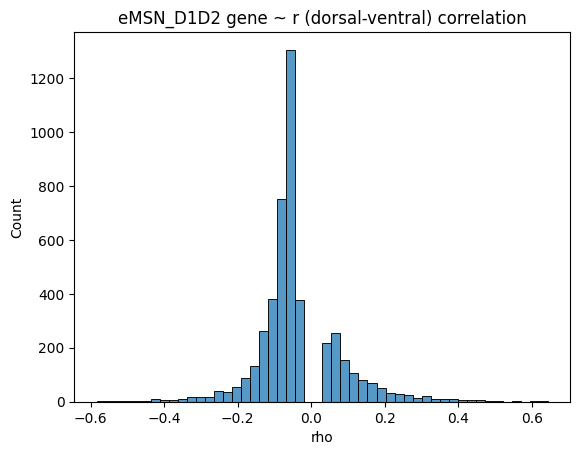

Matrix: 9240 / 24511 genes pass padj<0.05, pct_expr>=0.2, mean_expr>=0.1


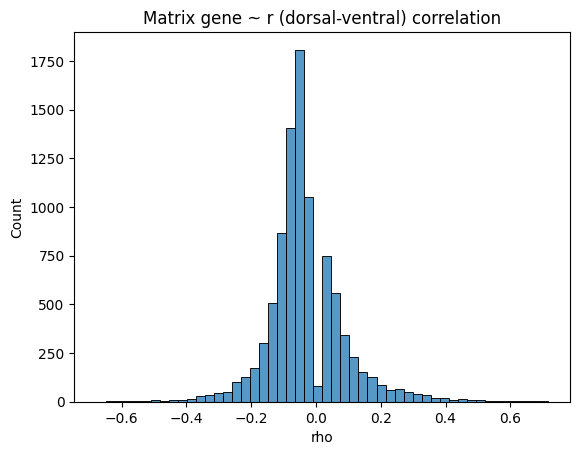

,rho,pval,tau2,z_mean,se,n_donors,padj,pct_expr,mean_expr,log2fc
CNR1,0.643054,1.030008e-98,0.019625,0.763364,0.036199,18,2.103877e-95,0.932297,22.941451,0.951306
ELL2,0.610216,7.385624e-142,0.010218,0.709266,0.027970,18,1.810290e-137,0.594819,4.286528,0.656888
NDST3,-0.582899,1.415796e-98,0.014109,-0.666842,0.031645,18,2.669428e-95,0.538515,6.049050,-0.821039
KCNT1,0.560277,3.693025e-73,0.018100,0.633237,0.035001,18,2.743022e-70,0.928843,7.707772,0.564394
MCTP1,0.552224,6.409448e-47,0.029598,0.621576,0.043209,18,1.671298e-44,0.993782,92.999136,0.826861
...,...,...,...,...,...,...,...,...,...,...
IRF8,NaN,1.000000e+00,0.000000,0.000000,0.013538,18,1.000000e+00,0.000000,0.000000,0.000000
SALRNA1,NaN,1.000000e+00,0.000000,0.000000,0.013538,18,1.000000e+00,0.000000,0.000000,0.000000
OR51B6,NaN,1.000000e+00,0.000000,0.000000,0.013538,18,1.000000e+00,0.000000,0.000000,0.000000
OR51C1P,NaN,1.000000e+00,0.000000,0.000000,0.013538,18,1.000000e+00,0.000000,0.000000,0.000000


In [35]:
CORR_DIR = "/home/gdallagl/myworkdir/XDP/data/BICAN/bican_spatial_zonated/genes_correlation"
PADJ_THR, MIN_PCT_EXPR, MIN_MEAN_EXPR = 0.05, 0.20, 0.10

def load_corr_weights(csv_name, label):
    df = pd.read_csv(f"{CORR_DIR}/{csv_name}", index_col=0)
    passes = (
        (df["padj"] < PADJ_THR) &
        (df["pct_expr"] >= MIN_PCT_EXPR) &
        (df["mean_expr"] >= MIN_MEAN_EXPR)
    )
    print(f"{label}: {passes.sum()} / {len(df)} genes pass padj<{PADJ_THR}, pct_expr>={MIN_PCT_EXPR}, mean_expr>={MIN_MEAN_EXPR}")
    df.loc[~passes, "rho"] = np.nan
    sns.histplot(df["rho"], bins=50); plt.title(f"{label} gene ~ r (dorsal-ventral) correlation"); plt.show()
    return df


df_corr_r_d1d2 = load_corr_weights("df_corr_r_d1d2.csv", "eMSN_D1D2")
weights_r = df_corr_r_d1d2["rho"]

df_corr_r_matrix = load_corr_weights("df_corr_r_matrix.csv", "Matrix")
weights_r_matrix = df_corr_r_matrix["rho"]

df_corr_r_d1d2.sort_values("rho", key=np.abs, ascending=False)


## 2. Load SlideTags dataset

In [36]:
slidetag = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/all_lib_adata_zoned_ct-cured_aligned.h5ad", backed="r")
# slidetag.obs["image"] = slidetag.obs["sample"].astype(str) + slidetag.obs["puck"].astype(str)
# slidetag.obs["image"] = np.where(slidetag.obs["has_spatial"], slidetag.obs["image"], np.nan)
slidetag.obs["condition"] = slidetag.obs["condition"].map({"healthy": "Control", "diseased": "XDP", "d iseased": "XDP"})
slidetag


AnnData object with n_obs × n_vars = 537658 × 37464 backed at '/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/all_lib_adata_zoned_ct-cured_aligned.h5ad'
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'has_spatial', 'sample', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id', 'donor_number', 'donor_id', 'condition', 'sex', 'age_at_onset', 'age_at_death', 'bcl', 'library', 'Sorted', 'mapping_coupling_for_zoning', 'zone'

## 3. Set the score scale(s) from SlideTags' own populations (no external reference)

The raw score for a cell is `raw_score = X @ weights` — the dot product of its log1p-normalized
expression (genes restricted to those with a weight) and a gene-weight vector. This is normalized
to `score = (raw_score - score_min) / (score_max - score_min)`.

Two independent scales are fixed here, each pooled across **every** matching cell in SlideTags
(all samples, both Control and XDP) — not from a separate reference dataset:
- `score_min_r` / `score_max_r` — from eMSN_D1D2 cells' `raw_score` under `weights_r`. Used for
  `dv_score_r` and, via spatial propagation, `DV_score_physical`.
- `score_min_r_matrix` / `score_max_r_matrix` — from Matrix_D1/Matrix_D2 cells' `raw_score` under
  `weights_r_matrix`. Used for `dv_score_r_matrix`, Matrix cells' own transcriptional score.

Fixing each scale once and reusing it for every sample keeps values comparable across
samples/conditions. Any linear rescale of `score_min`/`score_max` leaves the correlation test in
§5 unchanged — it only matters for comparing absolute score levels.

In [37]:
def compute_raw_score(adata, weights, layer=None, score_min=None, score_max=None):
    weights = weights.dropna()
    available = [g for g in weights.index if g in adata.var_names]
    print(f"Using {len(available)} / {len(weights)} genes for scoring")
    w = weights[available].values
    X = adata[:, available].layers[layer].toarray() if layer else adata[:, available].X.toarray()
    score = X @ w
    if score_min is None or score_max is None:
        score_min = score.min()
        score_max = score.max()
    else:
        print(f"Projection of query dataset: using provided score_min={score_min:.4f}, score_max={score_max:.4f}")
    score = (score - score_min) / (score_max - score_min)
    return score, score_min, score_max


def fit_scale(ct_values, weights, label):
    """Pool cells of the given ct_for_deg value(s) across all SlideTags samples/conditions,
    return the raw-score min/max that fixes that signature's [0, 1] scale."""
    pool = slidetag[
        slidetag.obs["ct_for_deg"].isin(ct_values) & slidetag.obs["has_spatial"]
    ].to_memory().copy()
    pool.var_names = pool.var["gene_symbol"].values.astype(str)
    pool.var_names_make_unique()

    _, score_min, score_max = compute_raw_score(pool, weights, layer="log1p_norm")
    print(f"{label}: score_min={score_min:.4f}, score_max={score_max:.4f} (n={pool.n_obs:,} cells pooled)")
    return score_min, score_max


score_min_r, score_max_r = fit_scale(["eMSN_D1D2"], weights_r, "D1D2 (weights_r)")
score_min_r_matrix, score_max_r_matrix = fit_scale(["Matrix_D1", "Matrix_D2"], weights_r_matrix, "Matrix (weights_r_matrix)")


Using 4638 / 4642 genes for scoring
D1D2 (weights_r): score_min=-159.4763, score_max=42.8813 (n=5,286 cells pooled)
Using 9228 / 9240 genes for scoring
Matrix (weights_r_matrix): score_min=-234.0357, score_max=139.6264 (n=31,800 cells pooled)


## 4. Score cells with their own signature, propagate D1D2 score to Matrix by spatial proximity

For each sample:
- score eMSN_D1D2 cells with `dv_score_r` — their own expression, D1D2 gene weights (`weights_r`)
  + the D1D2 scale from §3;
- score Matrix cells with `dv_score_r_matrix` — their own expression, **Matrix's own** gene
  weights (`weights_r_matrix`, not the D1D2 signature) + the Matrix scale from §3;
- separately, for each Matrix cell, average the `dv_score_r` of eMSN_D1D2 cells within `radius`
  (physical units) to get a spatially-propagated "physical" DV score (`DV_score_physical`) — this
  one is still built from the D1D2 signature, since it asks "what D1D2-ness would you predict
  here, purely from nearby eMSN_D1D2 cells."

sample_01
Using 4638 / 4642 genes for scoring
Projection of query dataset: using provided score_min=-159.4763, score_max=42.8813
Using 9228 / 9240 genes for scoring
Projection of query dataset: using provided score_min=-234.0357, score_max=139.6264


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


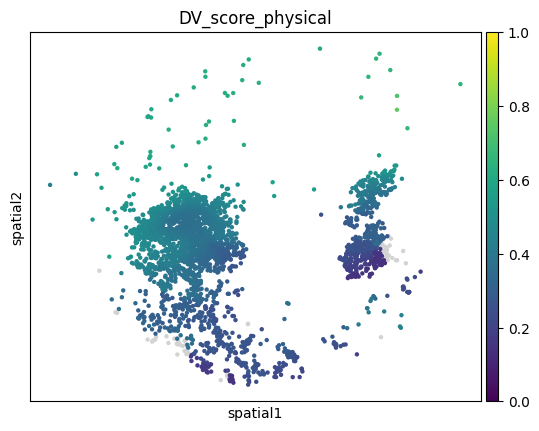

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


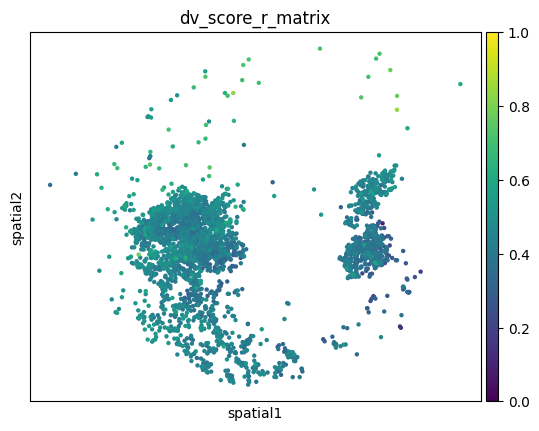

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


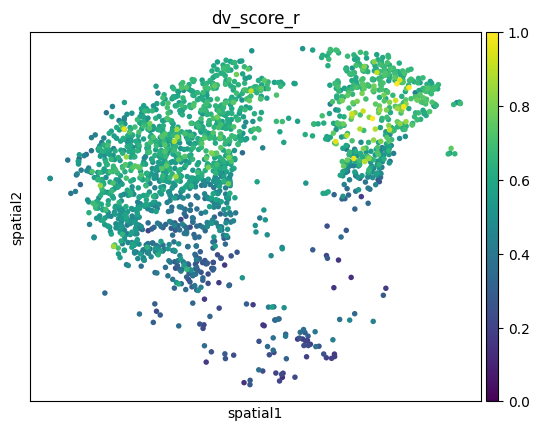

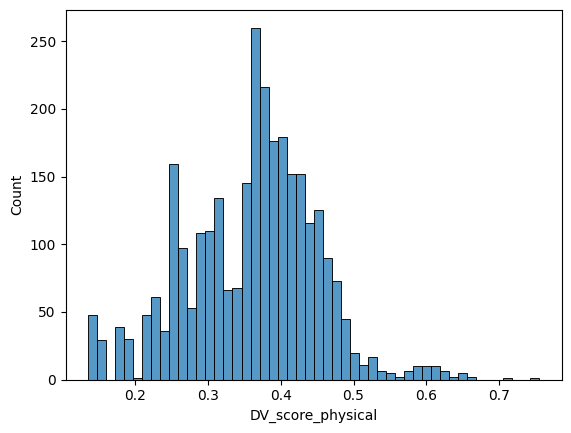

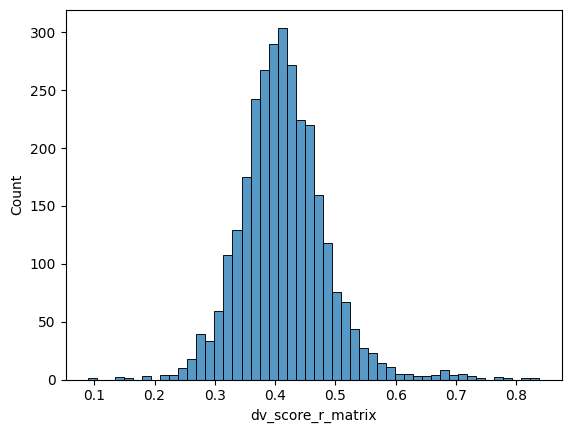

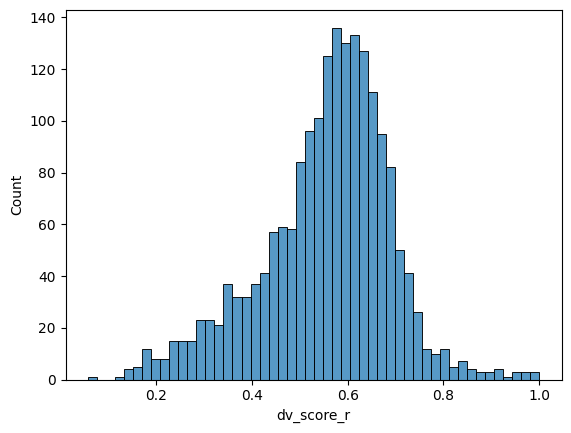

sample_02
Using 4638 / 4642 genes for scoring
Projection of query dataset: using provided score_min=-159.4763, score_max=42.8813
Using 9228 / 9240 genes for scoring
Projection of query dataset: using provided score_min=-234.0357, score_max=139.6264


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


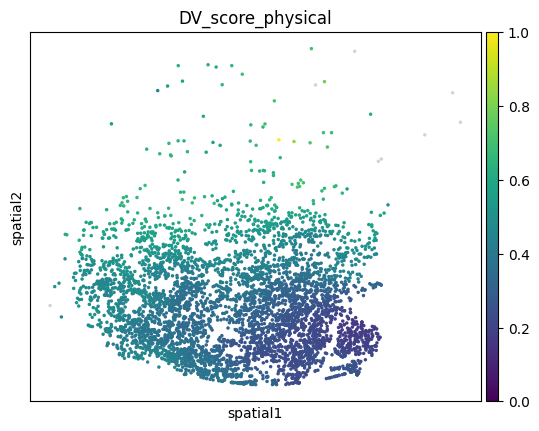

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


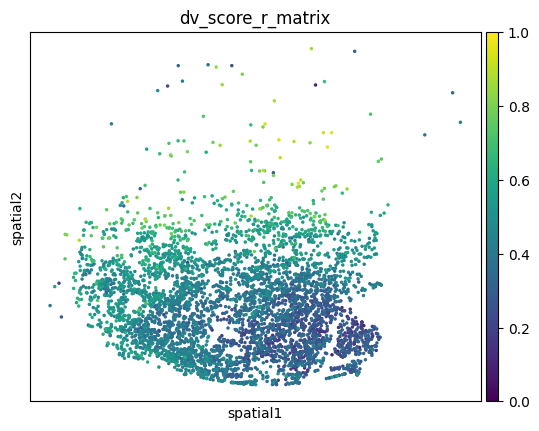

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


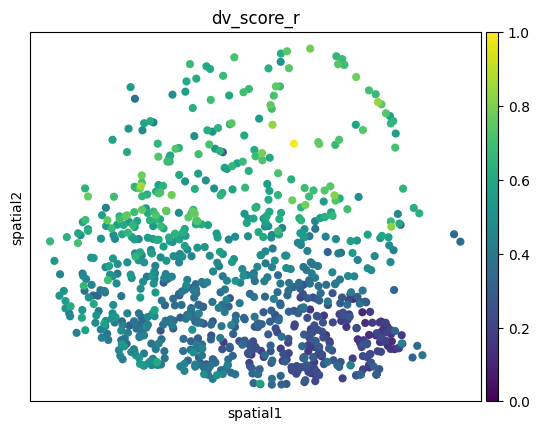

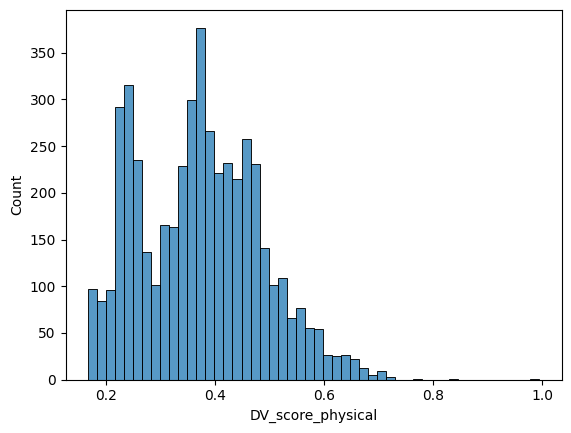

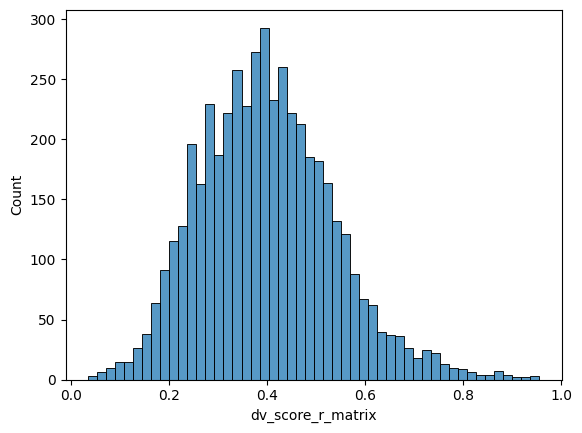

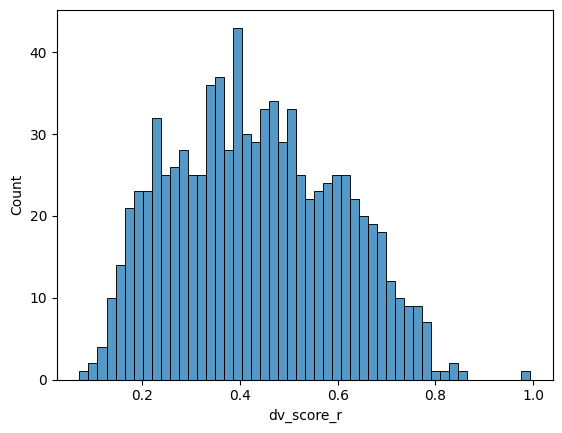

sample_03
Using 4638 / 4642 genes for scoring
Projection of query dataset: using provided score_min=-159.4763, score_max=42.8813
Using 9228 / 9240 genes for scoring
Projection of query dataset: using provided score_min=-234.0357, score_max=139.6264


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


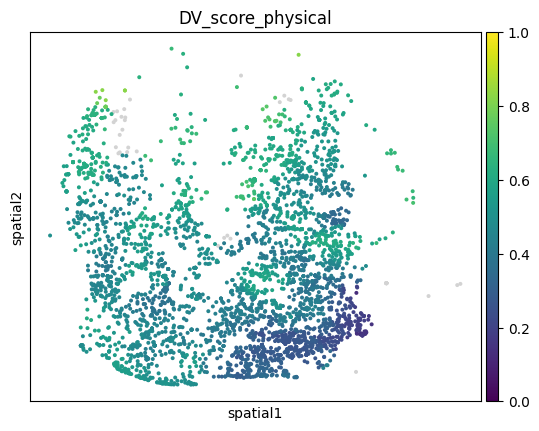

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


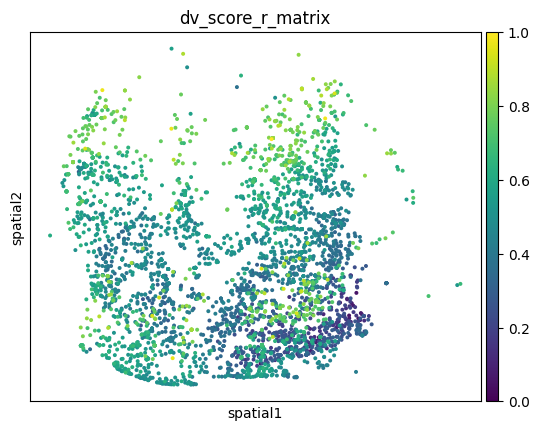

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


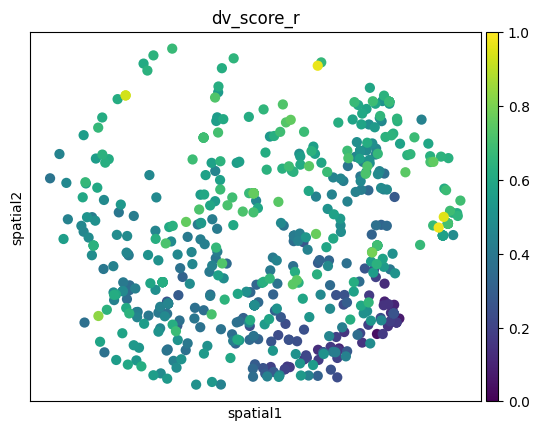

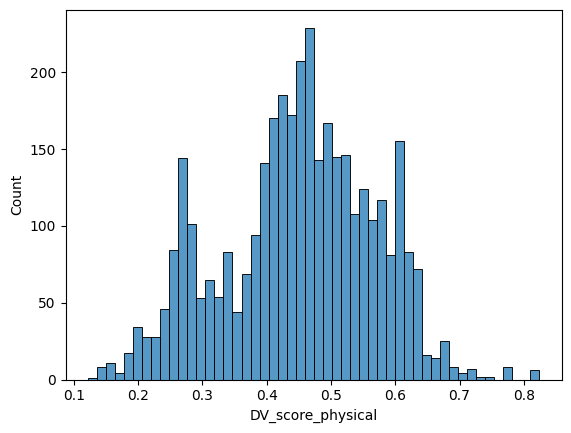

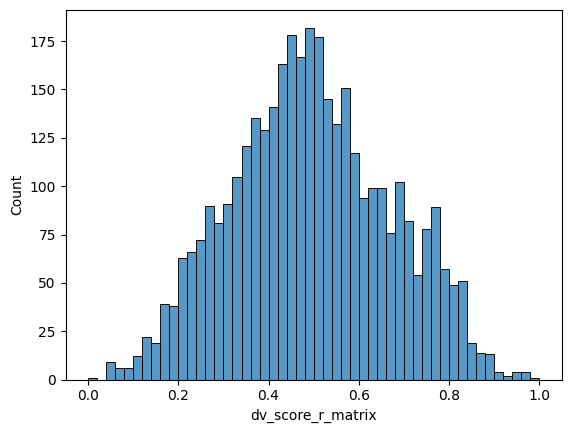

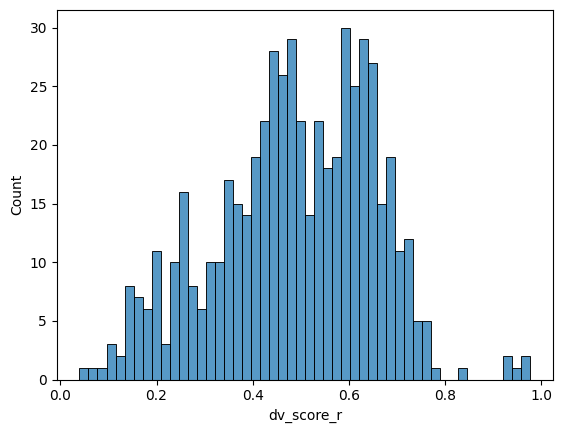

sample_04
Using 4638 / 4642 genes for scoring
Projection of query dataset: using provided score_min=-159.4763, score_max=42.8813
Using 9228 / 9240 genes for scoring
Projection of query dataset: using provided score_min=-234.0357, score_max=139.6264


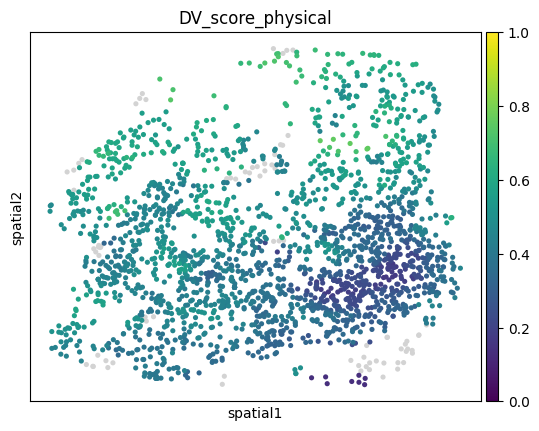

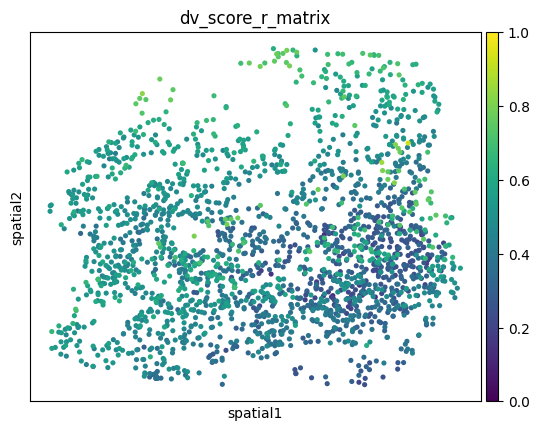

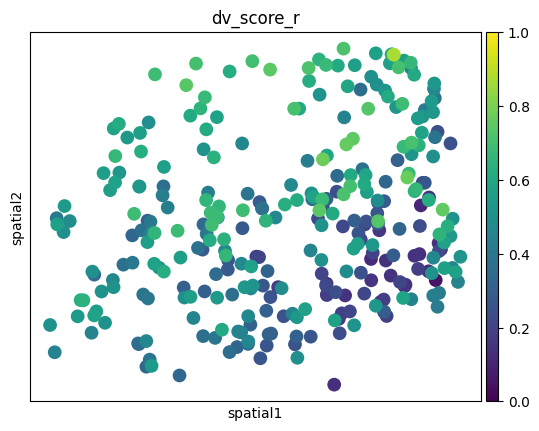

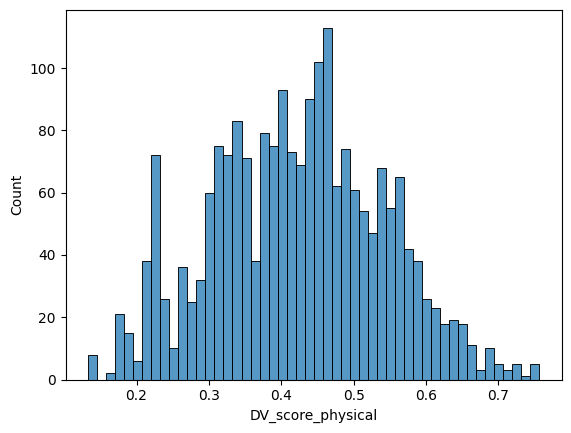

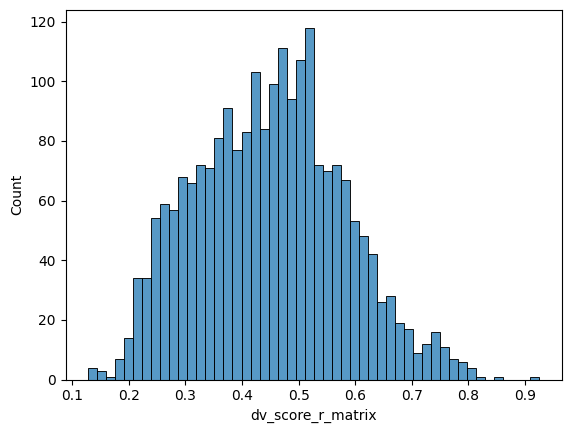

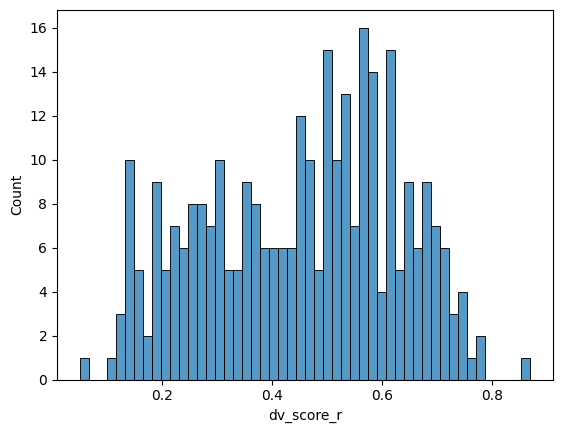

sample_05
Using 4638 / 4642 genes for scoring
Projection of query dataset: using provided score_min=-159.4763, score_max=42.8813
Using 9228 / 9240 genes for scoring
Projection of query dataset: using provided score_min=-234.0357, score_max=139.6264


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


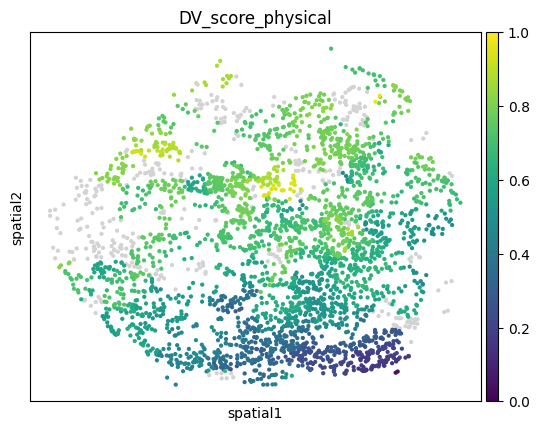

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


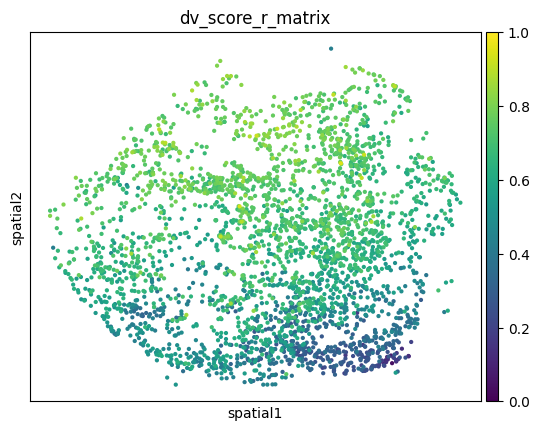

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


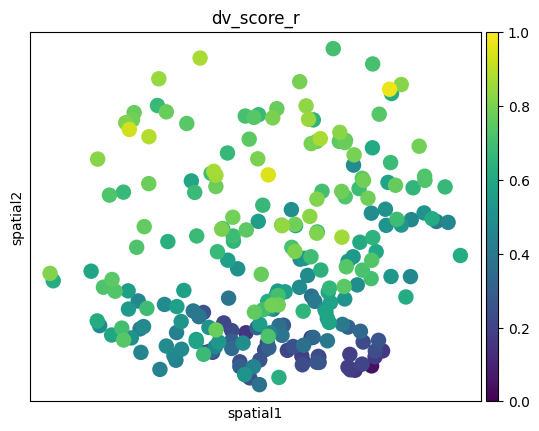

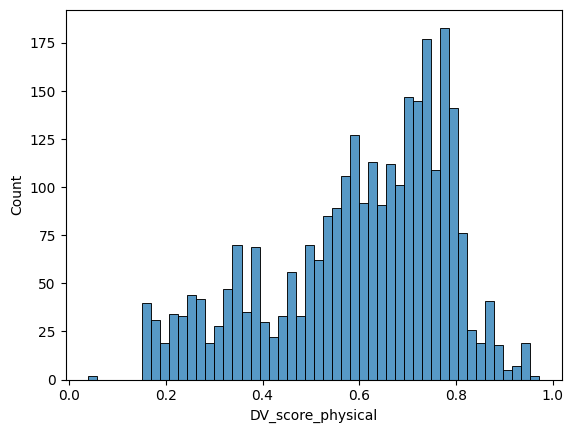

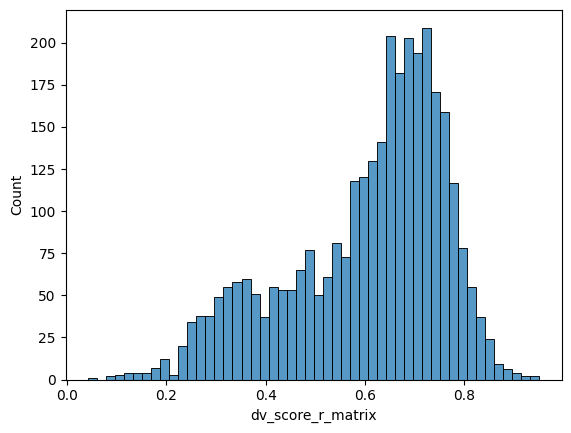

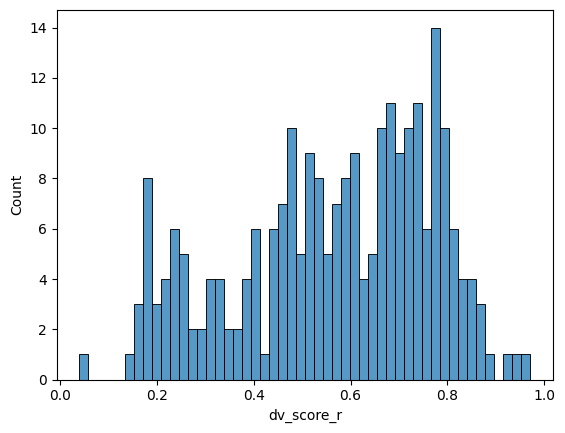

sample_06
Using 4638 / 4642 genes for scoring
Projection of query dataset: using provided score_min=-159.4763, score_max=42.8813
Using 9228 / 9240 genes for scoring
Projection of query dataset: using provided score_min=-234.0357, score_max=139.6264


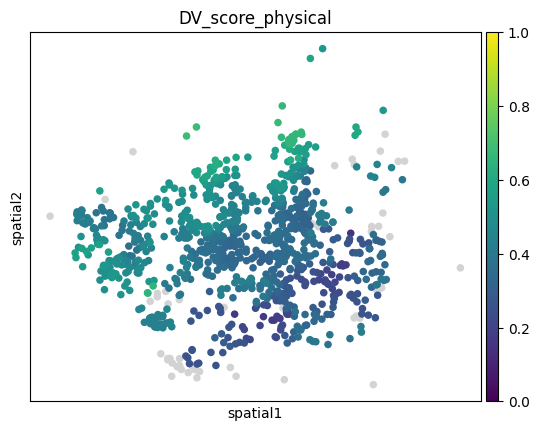

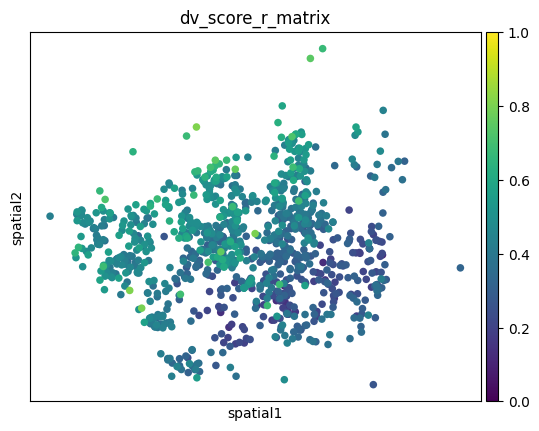

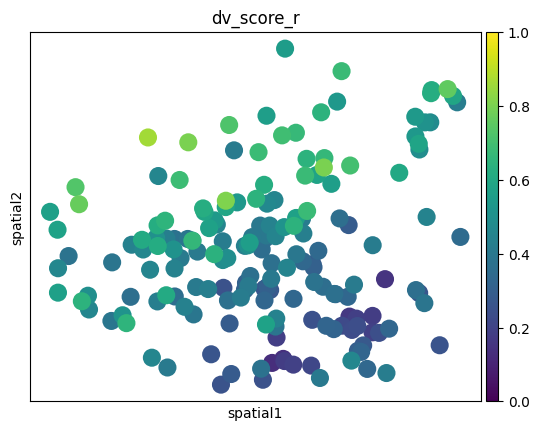

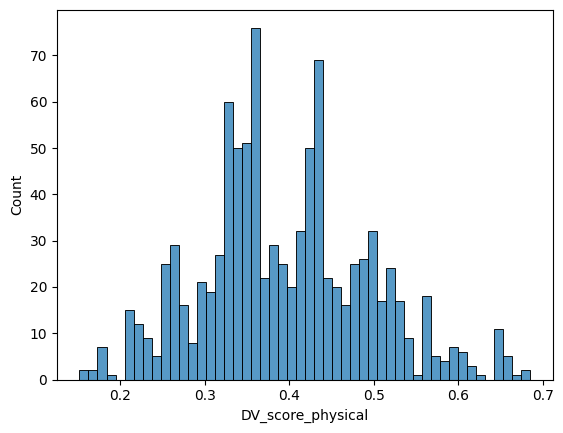

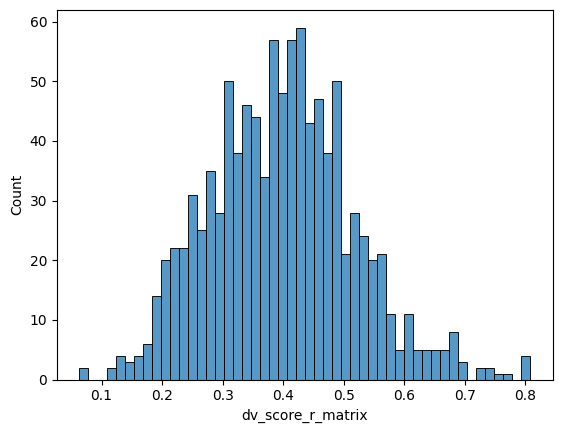

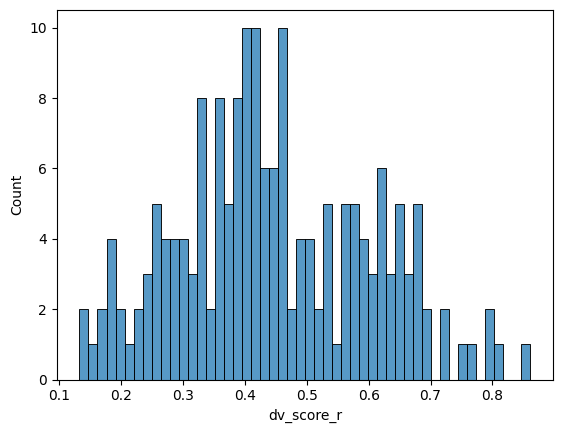

sample_07
Using 4638 / 4642 genes for scoring
Projection of query dataset: using provided score_min=-159.4763, score_max=42.8813
Using 9228 / 9240 genes for scoring
Projection of query dataset: using provided score_min=-234.0357, score_max=139.6264


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


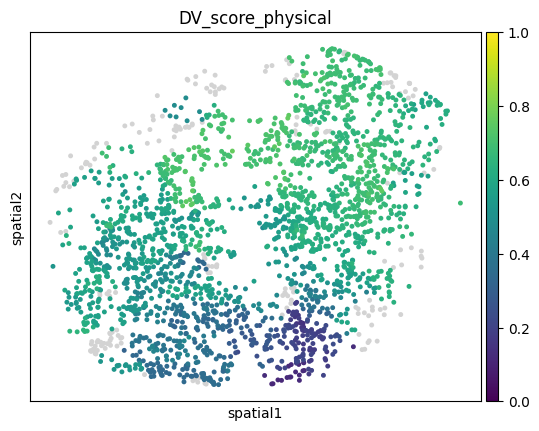

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


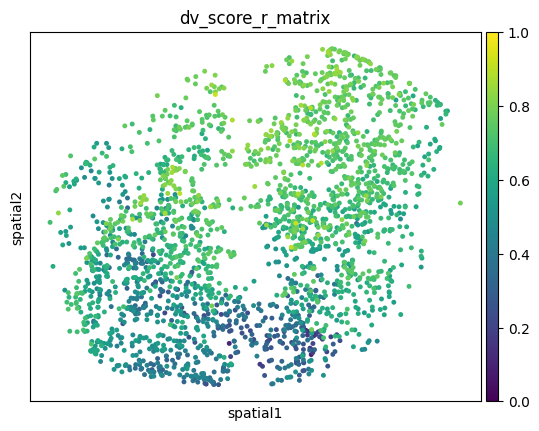

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


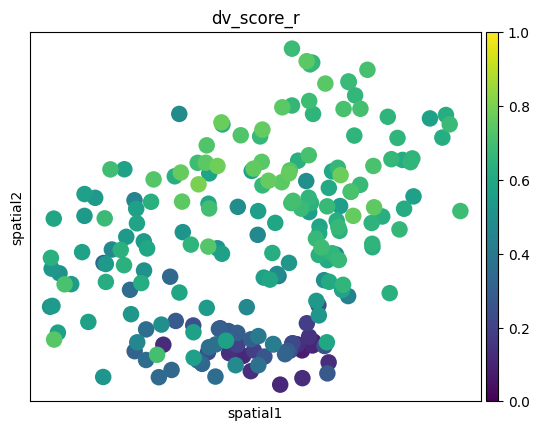

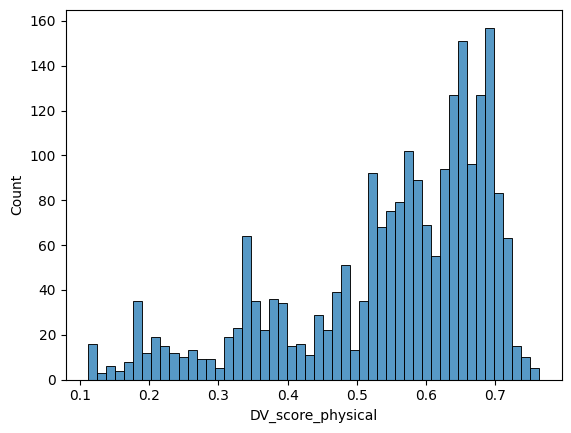

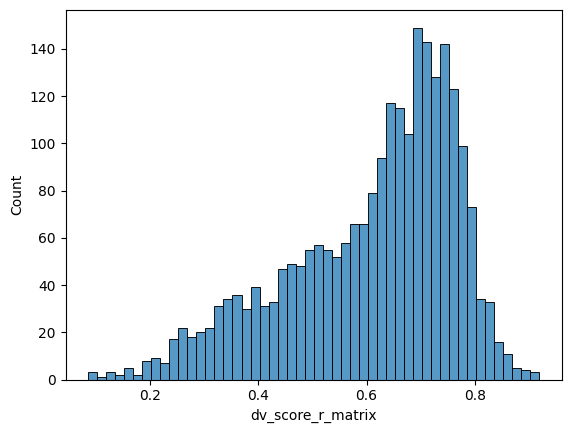

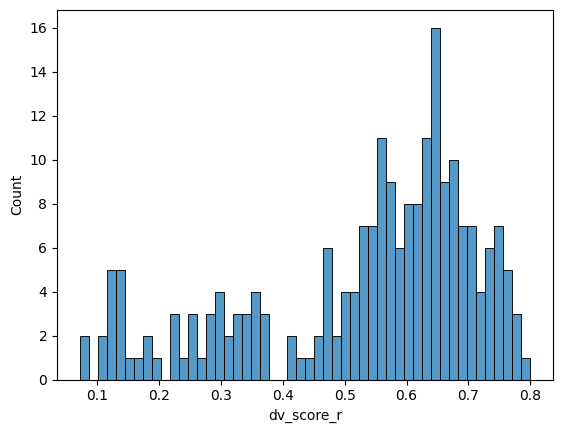

sample_08
Skipping sample_08: no cells after filtering
sample_09
Using 4638 / 4642 genes for scoring
Projection of query dataset: using provided score_min=-159.4763, score_max=42.8813
Using 9228 / 9240 genes for scoring
Projection of query dataset: using provided score_min=-234.0357, score_max=139.6264


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


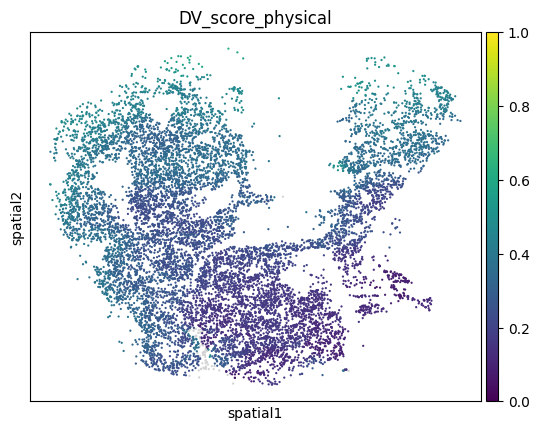

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


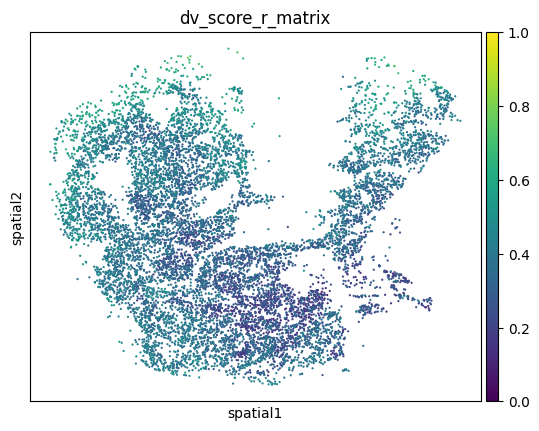

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


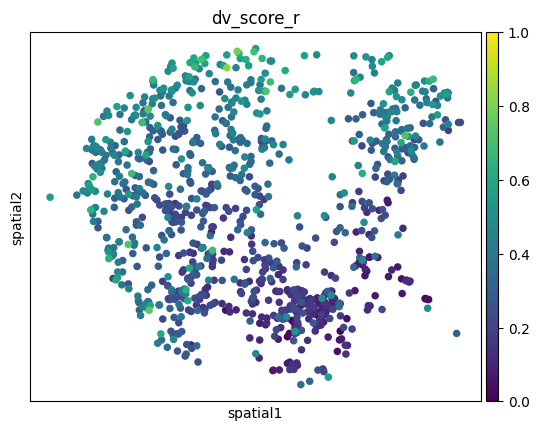

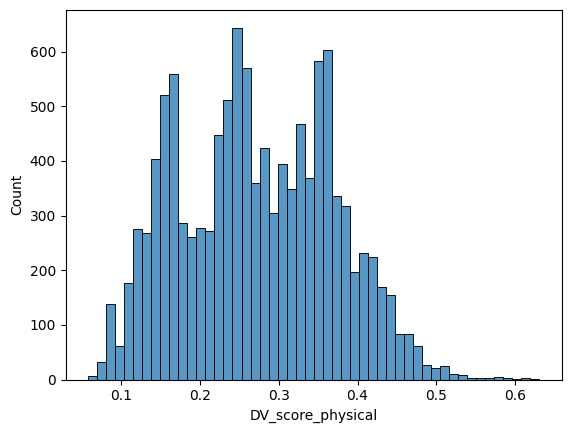

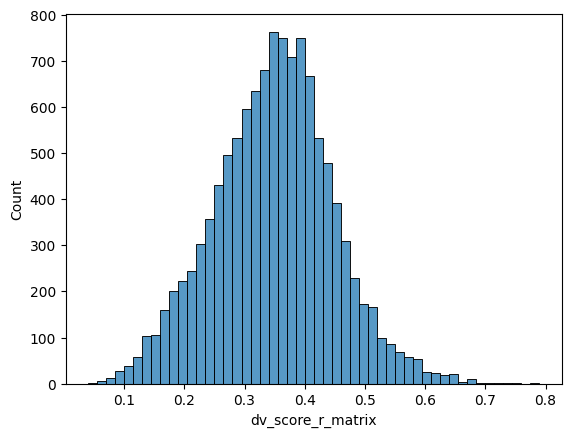

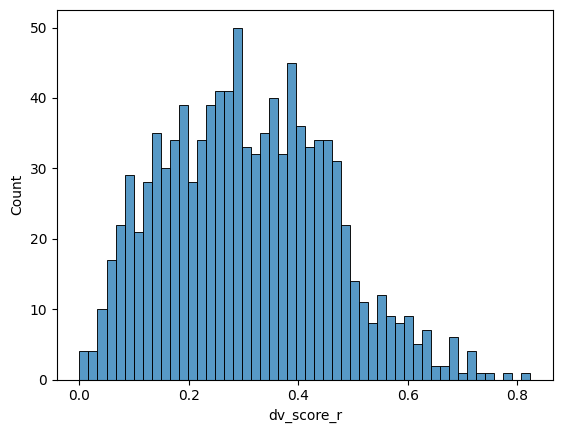

In [38]:
radius = 1500  # physical distance, same units as adata.obsm["spatial"]

for sample in slidetag.obs["sample"].dropna().unique():

    print(sample)

    slidetag_image = slidetag[
        (slidetag.obs["sample"] == sample) &
        (slidetag.obs["ct_for_deg"].isin(["eMSN_D1D2", "Matrix_D1", "Matrix_D2"])) &
        (slidetag.obs["has_spatial"])
    ].to_memory().copy()

    if slidetag_image.n_obs == 0:
        print(f"Skipping {sample}: no cells after filtering")
        continue

    # Slidetag (after remapping var_names to gene symbols)
    slidetag_image.var_names = slidetag_image.var["gene_symbol"].values.astype(str)
    slidetag_image.var_names_make_unique()

    d1d2_mask = slidetag_image.obs["ct_for_deg"] == "eMSN_D1D2"
    matrix_mask = slidetag_image.obs["ct_for_deg"].isin(["Matrix_D1", "Matrix_D2"])

    # transcriptional D1D2 score (eMSN_D1D2 cells only, D1D2 gene weights)
    slidetag_image.obs["dv_score_r"] = np.nan
    slidetag_image.obs.loc[d1d2_mask, "dv_score_r"], _, _ = compute_raw_score(
        slidetag_image[d1d2_mask], weights_r, layer="log1p_norm",
        score_min=score_min_r, score_max=score_max_r,
    )

    # transcriptional Matrix score (Matrix cells only, Matrix's own gene weights)
    slidetag_image.obs["dv_score_r_matrix"] = np.nan
    slidetag_image.obs.loc[matrix_mask, "dv_score_r_matrix"], _, _ = compute_raw_score(
        slidetag_image[matrix_mask], weights_r_matrix, layer="log1p_norm",
        score_min=score_min_r_matrix, score_max=score_max_r_matrix,
    )

    # physical score for Matrix cells: mean dv_score_r (D1D2 signature) of eMSN_D1D2 neighbors within radius
    d1d2_coords = slidetag_image[d1d2_mask].obsm["spatial"]
    d1d2_scores = slidetag_image.obs.loc[d1d2_mask, "dv_score_r"].values

    matrix_coords = slidetag_image[matrix_mask].obsm["spatial"]
    matrix_idx = slidetag_image.obs.index[matrix_mask]

    tree = KDTree(d1d2_coords)
    neighbor_indices = tree.query_ball_point(matrix_coords, r=radius)

    dv_physical = np.array([
        np.mean(d1d2_scores[idxs]) if len(idxs) > 0 else np.nan
        for idxs in neighbor_indices
    ])

    slidetag_image.obs["DV_score_physical"] = np.nan
    slidetag_image.obs.loc[matrix_idx, "DV_score_physical"] = dv_physical

    sc.pl.embedding(slidetag_image[matrix_mask], basis="spatial", color="DV_score_physical", vmin=0, vmax=1)
    sc.pl.embedding(slidetag_image[matrix_mask], basis="spatial", color="dv_score_r_matrix", vmin=0, vmax=1)
    sc.pl.embedding(slidetag_image[d1d2_mask], basis="spatial", color="dv_score_r", vmin=0, vmax=1)
    sns.histplot(slidetag_image.obs[matrix_mask]["DV_score_physical"], bins=50); plt.show()
    sns.histplot(slidetag_image.obs[matrix_mask]["dv_score_r_matrix"], bins=50); plt.show()
    sns.histplot(slidetag_image.obs[d1d2_mask]["dv_score_r"], bins=50); plt.show()

    # write results back onto the full slidetag object
    slidetag.obs.loc[slidetag_image.obs.index, "dv_score_r"] = slidetag_image.obs["dv_score_r"].values
    slidetag.obs.loc[slidetag_image.obs.index, "dv_score_r_matrix"] = slidetag_image.obs["dv_score_r_matrix"].values
    slidetag.obs.loc[slidetag_image.obs.index, "DV_score_physical"] = slidetag_image.obs["DV_score_physical"].values


## 5. Ventralization test: does the Matrix cell's own transcriptional signature track its physical D1D2 proximity?

If ventralization is real, a Matrix cell's physical DV score (`DV_score_physical`, inferred purely
from nearby eMSN_D1D2 cells) should correlate with that same cell's own transcriptional score
computed from **Matrix's own gradient genes** (`dv_score_r_matrix`) — compared here between
Control and XDP.

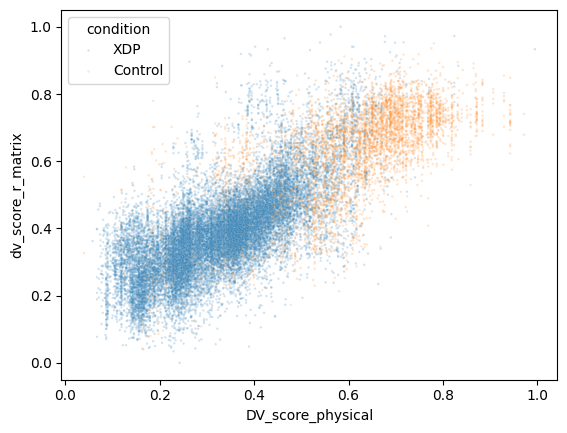

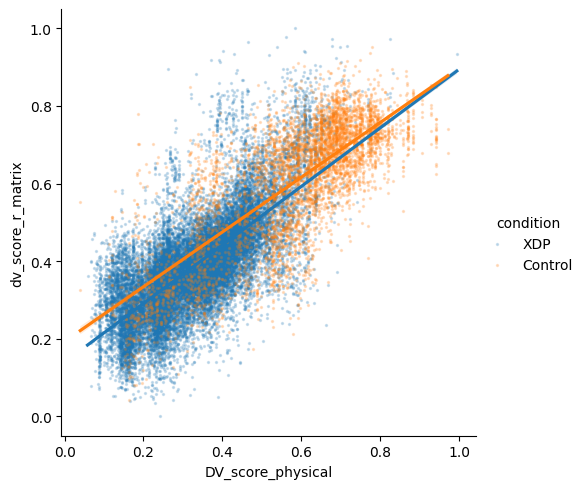

In [39]:
matrix_obs = slidetag.obs[slidetag.obs["ct_for_deg"].isin(["Matrix_D1", "Matrix_D2"])].copy()

sns.scatterplot(matrix_obs, x="DV_score_physical", y="dv_score_r_matrix", hue="condition", alpha=0.2, s=3); plt.show()
sns.lmplot(matrix_obs, x="DV_score_physical", y="dv_score_r_matrix", hue="condition", scatter_kws={"alpha": 0.2, "s": 2}); plt.show()


In [40]:
MSN_ct = ['Matrix_D1', 'Matrix_D2', 'Patch_D1', 'Patch_D2', 'eMSN_D1D2', 'eMSN_StrioMat', 'eMSN_NUDAP', 'TAFA1']
sample_02 = slidetag[
    (slidetag.obs["sample"] == "sample_02") &
    (slidetag.obs["ct_for_deg"].isin(MSN_ct)) &
    (slidetag.obs["has_spatial"])
].to_memory().copy()
sample_02


AnnData object with n_obs × n_vars = 8262 × 37464
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'has_spatial', 'sample', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id', 'donor_number', 'donor_id', 'condition', 'sex', 'age_at_onset', 'age_at_death', 'bcl', 'library', 'Sorted', 'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability', 'leiden_0.1_all_cel

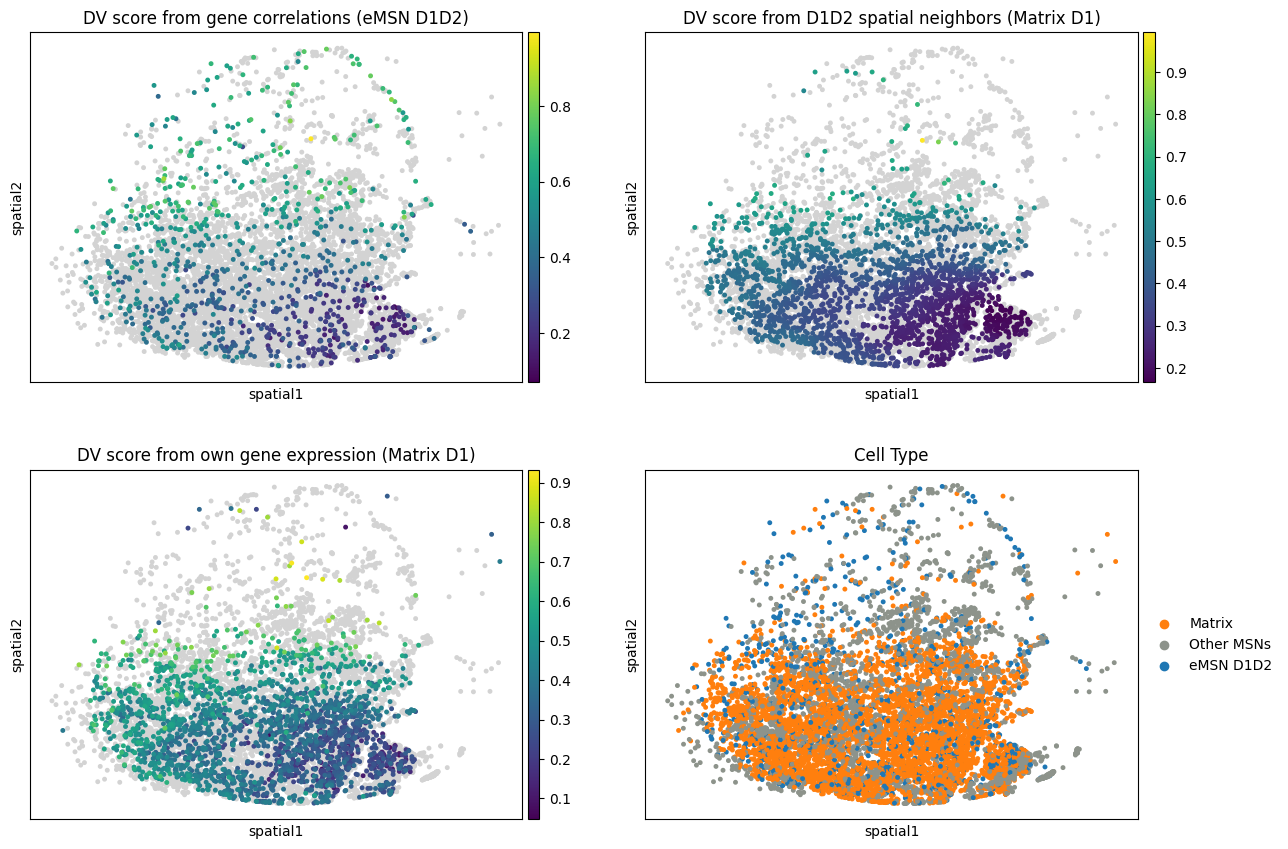

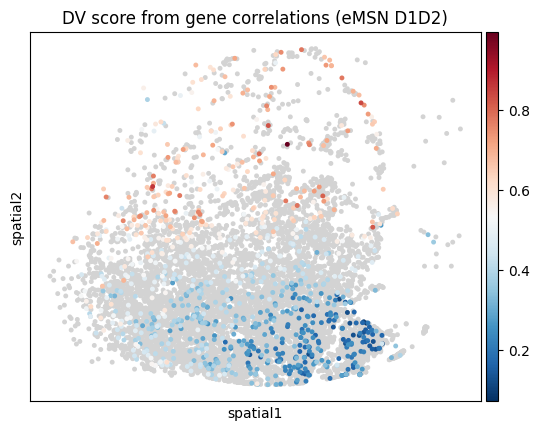

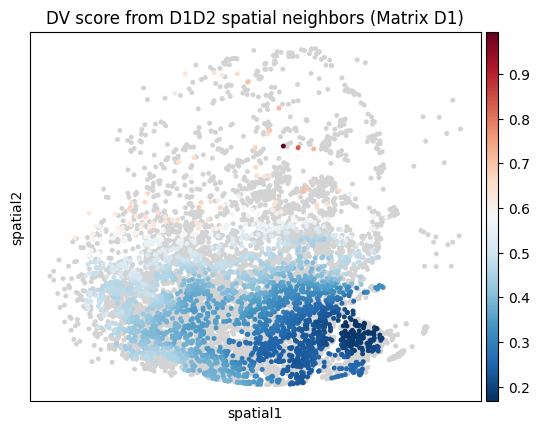

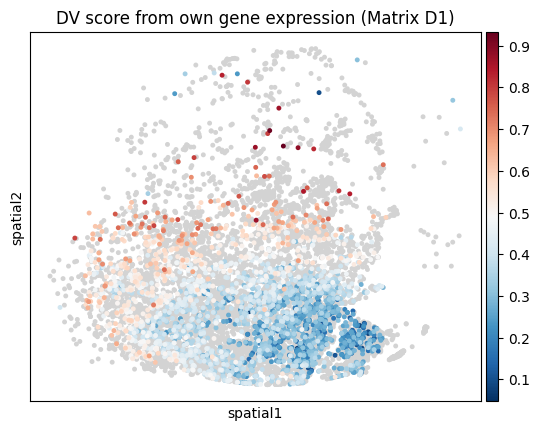

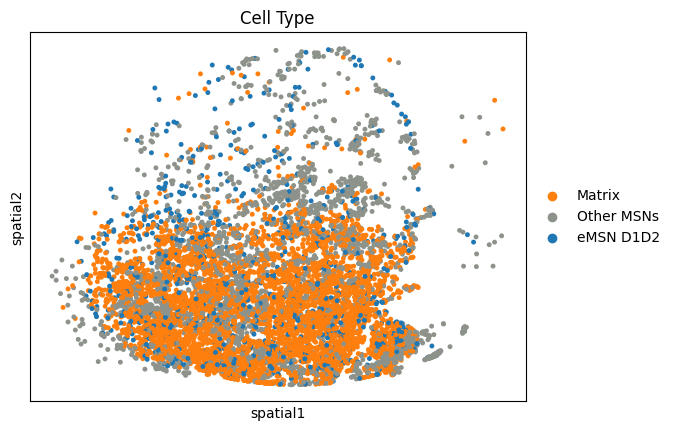

In [41]:
sample_02.obs["DV score from gene correlations (eMSN D1D2)"] = np.where(sample_02.obs["ct_for_deg"] == "eMSN_D1D2", sample_02.obs["dv_score_r"], np.nan)
sample_02.obs["DV score from own gene expression (Matrix D1)"] = np.where(sample_02.obs["ct_for_deg"] == "Matrix_D1", sample_02.obs["dv_score_r_matrix"], np.nan)
sample_02.obs["DV score from D1D2 spatial neighbors (Matrix D1)"] = np.where(sample_02.obs["ct_for_deg"] == "Matrix_D1", sample_02.obs["DV_score_physical"], np.nan)
sample_02.obs["Cell Type"] = sample_02.obs["ct_for_deg"].map({
    "eMSN_D1D2": "eMSN D1D2",
    "Matrix_D1": "Matrix",
    "Matrix_D2": "Matrix",
}).fillna("Other MSNs")

palette = {
    "eMSN D1D2": "#1f77b4",
    "Matrix": "#ff7f0e",
    "Other MSNs": "#8d938b",
}

sc.pl.embedding(
    sample_02,
    basis="spatial",
    color=[
        "DV score from gene correlations (eMSN D1D2)",
        "DV score from D1D2 spatial neighbors (Matrix D1)",
        "DV score from own gene expression (Matrix D1)",
        "Cell Type"
    ],
    ncols=2,
    palette=palette,
    size=50,
)

for color in [
        "DV score from gene correlations (eMSN D1D2)",
        "DV score from D1D2 spatial neighbors (Matrix D1)",
        "DV score from own gene expression (Matrix D1)",
        "Cell Type"
    ]:
    sc.pl.embedding(
        sample_02,
        basis="spatial",
        color=color,
        palette=palette if color == "Cell Type" else None,
        size=50,
        cmap="RdBu_r" if color != "Cell Type" else None,
    ); plt.show()


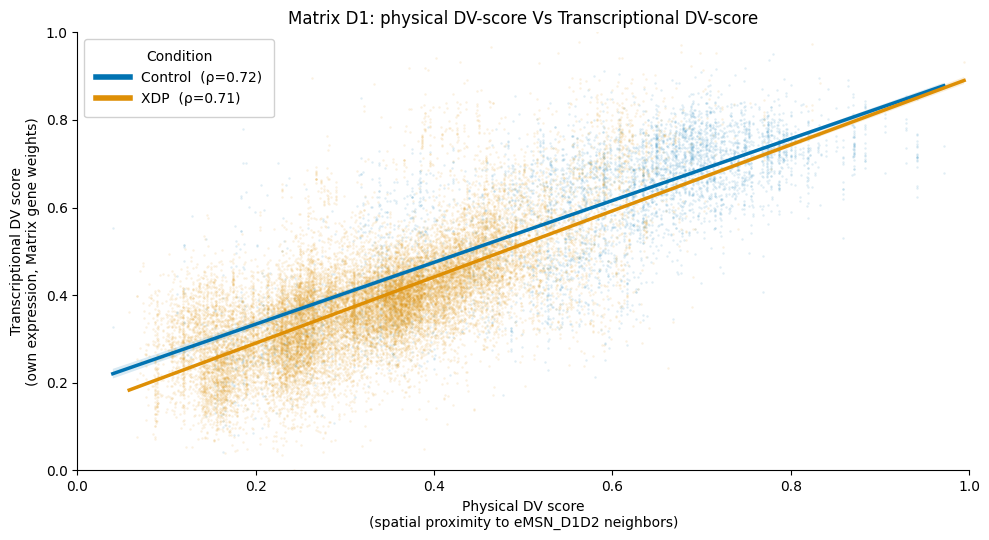

In [53]:
from scipy.stats import spearmanr
from matplotlib.lines import Line2D

matrix_obs = slidetag.obs[slidetag.obs["ct_for_deg"].isin(["Matrix_D1", "Matrix_D2"])].copy()
matrix_obs = matrix_obs.dropna(subset=["DV_score_physical", "dv_score_r_matrix", "condition"])

# fixed color per condition (colorblind-safe), not resampled hues
palette = {"Control": "#0173b2", "XDP": "#de8f05"}
conditions = ["Control", "XDP"]

fig, ax = plt.subplots(figsize=(10, 5.5))

legend_handles = []
for cond in conditions:
    sub = matrix_obs[matrix_obs["condition"] == cond]

    # rasterized, low-alpha scatter as a density hint under the fit
    ax.scatter(sub["DV_score_physical"], sub["dv_score_r_matrix"], s=3, alpha=0.12,
               color=palette[cond], linewidths=0, rasterized=True)

    # regression line + 95% CI band (no label here — legend built manually below)
    sns.regplot(data=sub, x="DV_score_physical", y="dv_score_r_matrix", scatter=False,
                ci=95, color=palette[cond], line_kws={"lw": 2.5}, ax=ax)

    rho, pval = spearmanr(sub["DV_score_physical"], sub["dv_score_r_matrix"])
    legend_handles.append(Line2D(
        [0], [0], color=palette[cond], lw=4,
        label=f"{cond}  (ρ={rho:.2f})",
    ))

ax.legend(handles=legend_handles, loc="upper left", frameon=True, framealpha=0.9,
          fontsize=10, title="Condition", handlelength=2.5, borderpad=0.8)
ax.set_xlabel("Physical DV score\n(spatial proximity to eMSN_D1D2 neighbors)")
ax.set_ylabel("Transcriptional DV score\n(own expression, Matrix gene weights)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Matrix D1: physical DV-score Vs Transcriptional DV-score")

plt.tight_layout()
plt.show()


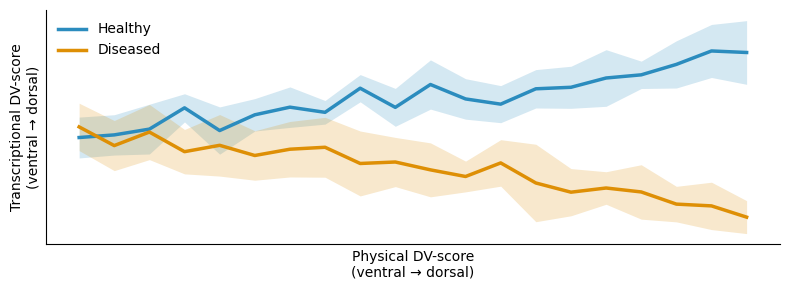

In [51]:
"""
Physical DV-score vs Transcriptional DV-score
==============================================
Plots two lines (Healthy / Diseased), each with a shaded 95% confidence
interval band:
 
  x-axis : physical D-V axis position (ventral -> dorsal)
  y-axis : transcriptional D-V score  (ventral -> dorsal)
 
Healthy trends UP (transcriptional score tracks physical position normally).
Diseased trends DOWN (patterning is inverted/disrupted).
 
Replace the SYNTHETIC DATA block below with your own measurements -
see the "USING YOUR OWN DATA" section at the bottom for how to plug in
a CSV instead.
"""
 
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
 
rng = np.random.default_rng(42)
 
# --------------------------------------------------------------------
# 1. SYNTHETIC DATA (swap this out for your real measurements)
# --------------------------------------------------------------------
# Physical D-V axis, normalized 0 (ventral) -> 1 (dorsal)
x = np.linspace(0, 1, 20)
 
n_replicates = 8  # e.g. number of animals / organoids / sections per group
 
start_height = 0.5  # both lines start here at the ventral-most position
slope = 0.05      # small slope -> gentle divergence, not a steep V
 
# Healthy: transcriptional DV score rises gently with physical position
healthy_reps = np.array(
    [start_height + slope * x + rng.normal(0, 0.02, size=x.shape)
     for _ in range(n_replicates)]
)
 
# Diseased: transcriptional DV score falls gently as physical position increases
diseased_reps = np.array(
    [start_height - slope * x + rng.normal(0, 0.02, size=x.shape)
     for _ in range(n_replicates)]
)
 
 
# --------------------------------------------------------------------
# 2. Mean + 95% CI (t-distribution, appropriate for small n)
# --------------------------------------------------------------------
def mean_and_ci(data_2d, confidence=0.95):
    """data_2d: array of shape (n_replicates, n_positions)."""
    n = data_2d.shape[0]
    mean = data_2d.mean(axis=0)
    sem = data_2d.std(axis=0, ddof=1) / np.sqrt(n)
    t_val = stats.t.ppf((1 + confidence) / 2.0, df=n - 1)
    ci = t_val * sem
    return mean, ci
 
 
healthy_mean, healthy_ci = mean_and_ci(healthy_reps)
diseased_mean, diseased_ci = mean_and_ci(diseased_reps)
 
 
# --------------------------------------------------------------------
# 3. Plot
# --------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 3))
 
healthy_color = "#2b8cbe"
diseased_color = "#de8f05"
 
ax.plot(x, healthy_mean, color=healthy_color, lw=2.5, label="Healthy")
ax.fill_between(
    x, healthy_mean - healthy_ci, healthy_mean + healthy_ci,
    color=healthy_color, alpha=0.2, linewidth=0,
)
 
ax.plot(x, diseased_mean, color=diseased_color, lw=2.5, label="Diseased")
ax.fill_between(
    x, diseased_mean - diseased_ci, diseased_mean + diseased_ci,
    color=diseased_color, alpha=0.2, linewidth=0,
)
 
ax.set_xlabel("Physical DV-score\n(ventral → dorsal)")
ax.set_ylabel("Transcriptional DV-score\n(ventral → dorsal)")
# ax.set_title("Physical vs Transcriptional D-V Axis Score")
ax.legend(frameon=False, loc="best")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
 
plt.tight_layout()
# plt.savefig("dv_score_plot.png", dpi=200)
plt.show()